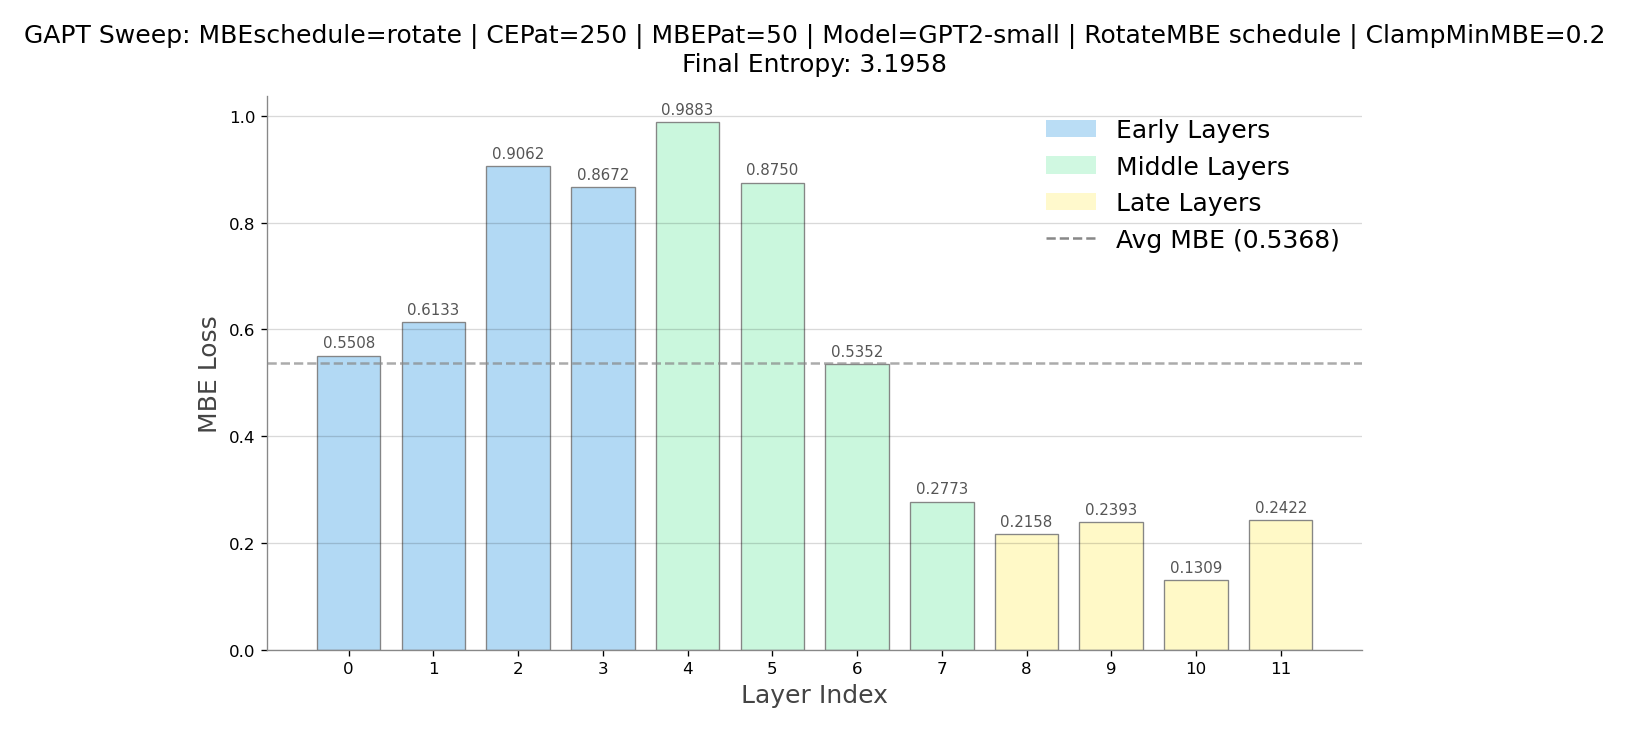

In [72]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/iblm-21.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [42]:
# Issue #1. Rotation adopting 'skip_last=1' -> last few layer MBE very low
#           this is not ideal, we want mid-layer to be compressed more


In [1]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/sorl-a1.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out

{k: loss_record[k][-1]for k in loss_record}

{'base_traj_loss': 1.0438,
 'cond_traj_loss (search)': 1.0471,
 'abs_loss (search)': 2.9882,
 'search_adv': 0.0571,
 'search_info_gain': -0.0024,
 'util_rate': 0.9027,
 'K': 8.0}

In [2]:
from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "logs/k_curriculum_dynamics.gif", run_info, val_interval=125, fps=5)

Fixed axis limits: {'loss_min': 0.99161, 'loss_max': 11.370555000000001, 'adv_min': -0.0049984796, 'adv_max': 0.0674, 'info_min': -0.0217, 'info_max': 0.0077}
Generated frame 10/15
GIF saved to: logs/k_curriculum_dynamics.gif
